# Frozen vs Evolving (Least Squares): Baseline vs +{7,8} Target

This notebook compares baseline and updated target families using reruns with full low-frequency support.

Compared cases:
- **Baseline**: `Ks = [0, 1, 2, 3, 4, 5, 6]`
- **Updated**: `Ks = [0, 1, 2, 3, 4, 5, 6, 7, 8]`

All plots are in least-squares objective units:
$$L(t)=\frac{1}{2}\|f_t(X_{train})-y_{train}\|_2^2.$$


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'utils').exists() and (ROOT.parent / 'utils').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

BASE_RESULTS = ROOT / 'results'
PLOT_DIR = ROOT / 'notebooks' / 'plots' / 'ntk_frozen_vs_evolving_old_vs_new_target_comparison'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

WIDTHS = [256, 512, 1024]
LS_OBJECTIVE = '0.5 * ||f(X_train)-y_train||^2'
N_GRID = 2048

CASE_SPECS = {
    'baseline': {
        'label': 'Baseline [0..6]',
        'target_ks': [0, 1, 2, 3, 4, 5, 6],
        'exp_name_fmt': 'ntk_frozen_vs_evolving_mode_dynamics_k0256_w{width}',
    },
    'k78': {
        'label': 'Updated [0..8]',
        'target_ks': [0, 1, 2, 3, 4, 5, 6, 7, 8],
        'exp_name_fmt': 'ntk_frozen_vs_evolving_mode_dynamics_k0256_78_w{width}',
    },
}

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

print('Project root:', ROOT)
print('Results base:', BASE_RESULTS)
print('Plots dir:', PLOT_DIR)


Project root: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments
Results base: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results
Plots dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_old_vs_new_target_comparison


In [2]:
def load_manifest(run_dir: Path) -> dict:
    return json.loads((run_dir / 'manifest.json').read_text())


def latest_run_dir_for_experiment(exp_name: str) -> Path:
    exp_dir = BASE_RESULTS / exp_name
    if not exp_dir.exists():
        raise FileNotFoundError(f'Missing experiment directory: {exp_dir}')

    latest = exp_dir / 'latest'
    if latest.exists():
        return latest.resolve()

    candidates = sorted([d for d in exp_dir.iterdir() if d.is_dir()])
    if not candidates:
        raise FileNotFoundError(f'No runs found in {exp_dir}')
    return candidates[-1]


def seed_mean_std(arr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(arr, dtype=float)
    return np.mean(arr, axis=0), np.std(arr, axis=0)


def phase_to_latex(phi: float) -> str:
    if np.isclose(phi, 0.0):
        return '0'
    if np.isclose(phi, np.pi / 2.0):
        return r'\frac{\pi}{2}'
    if np.isclose(phi, np.pi):
        return r'\pi'
    if np.isclose(phi, -np.pi / 2.0):
        return r'-\frac{\pi}{2}'
    return f'{phi:.3f}'


def target_formula_latex(meta: dict) -> str:
    terms = []
    for k, a, p in zip(meta['target_Ks'], meta['target_amps'], meta['target_phases']):
        k = int(k)
        a = float(a)
        p_tex = phase_to_latex(float(p))
        if p_tex == '0':
            terms.append(rf'{a:g}\cos({k}\theta)')
        else:
            terms.append(rf'{a:g}\cos({k}\theta + {p_tex})')
    return ' + '.join(terms)


def load_case_width_payload(case_key: str, width: int) -> dict:
    spec = CASE_SPECS[case_key]
    exp_name = spec['exp_name_fmt'].format(width=width)
    run_dir = latest_run_dir_for_experiment(exp_name)
    manifest = load_manifest(run_dir)
    meta = manifest['meta']

    if meta.get('target_Ks') != spec['target_ks']:
        raise ValueError(
            f"{exp_name}: target_Ks mismatch {meta.get('target_Ks')} != {spec['target_ks']}"
        )
    if int(meta.get('n_train', -1)) != N_GRID or int(meta.get('n_eval', -1)) != N_GRID:
        raise ValueError(f"{exp_name}: expected n_train=n_eval={N_GRID}")
    if meta.get('loss_objective') != LS_OBJECTIVE:
        raise ValueError(
            f"{exp_name}: objective mismatch {meta.get('loss_objective')} != {LS_OBJECTIVE}"
        )

    run_path = run_dir / manifest['runs'][str(width)]
    run = np.load(run_path)

    if 'train_loss_frozen' not in run or 'train_loss_evolving' not in run:
        raise ValueError(f"{run_path}: missing train_loss arrays")

    probe = np.load(run_dir / manifest['probe_geometry'])
    target = np.load(run_dir / manifest['target_task'])

    return {
        'exp_name': exp_name,
        'run_dir': run_dir,
        'run_id': run_dir.name,
        'manifest': manifest,
        'steps': np.asarray(run['snapshot_steps'], dtype=int),
        'loss_frozen': np.asarray(run['train_loss_frozen'], dtype=float),
        'loss_evolving': np.asarray(run['train_loss_evolving'], dtype=float),
        'gamma_eval': np.asarray(probe['gamma_eval'], dtype=float),
        'y_eval_true': np.asarray(target['y_eval_true'], dtype=float),
    }


In [3]:
payload = {k: {} for k in CASE_SPECS.keys()}
for case_key in CASE_SPECS.keys():
    for w in WIDTHS:
        payload[case_key][w] = load_case_width_payload(case_key, w)

for case_key, spec in CASE_SPECS.items():
    print(f'\n{spec["label"]}')
    for w in WIDTHS:
        p = payload[case_key][w]
        print(f'  w={w}: {p["run_id"]} ({p["exp_name"]})')


Baseline [0,2,5,6]
  w=256: 20260417-230013-db31e419 (ntk_frozen_vs_evolving_mode_dynamics_k02656_w256)
  w=512: 20260417-230844-2a769226 (ntk_frozen_vs_evolving_mode_dynamics_k02656_w512)
  w=1024: 20260417-231443-e74fa293 (ntk_frozen_vs_evolving_mode_dynamics_k02656_w1024)

Updated [0,2,5,6,7,8]
  w=256: 20260418-012344-60ebad3b (ntk_frozen_vs_evolving_mode_dynamics_k02656_78_w256)
  w=512: 20260418-012702-39a7e7ce (ntk_frozen_vs_evolving_mode_dynamics_k02656_78_w512)
  w=1024: 20260418-090854-c21f6076 (ntk_frozen_vs_evolving_mode_dynamics_k02656_78_w1024)


## Target Formulas

In [4]:
for case_key, spec in CASE_SPECS.items():
    meta = payload[case_key][256]['manifest']['meta']
    formula = target_formula_latex(meta)
    display(Markdown(f'**{spec["label"]}:**'))
    display(Markdown(rf'$$f(\theta) = {formula}$$'))

**Baseline [0,2,5,6]:**

$$f(\theta) = 1\cos(0\theta) + 0.8\cos(2\theta) + 0.55\cos(5\theta + \frac{\pi}{2}) + 0.55\cos(6\theta + \frac{\pi}{2})$$

**Updated [0,2,5,6,7,8]:**

$$f(\theta) = 1\cos(0\theta) + 0.8\cos(2\theta) + 0.55\cos(5\theta + \frac{\pi}{2}) + 0.55\cos(6\theta + \frac{\pi}{2}) + 0.55\cos(7\theta) + 0.55\cos(8\theta)$$

## Target Function Comparison

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_old_vs_new_target_comparison/target_function_baseline_vs_k78.png


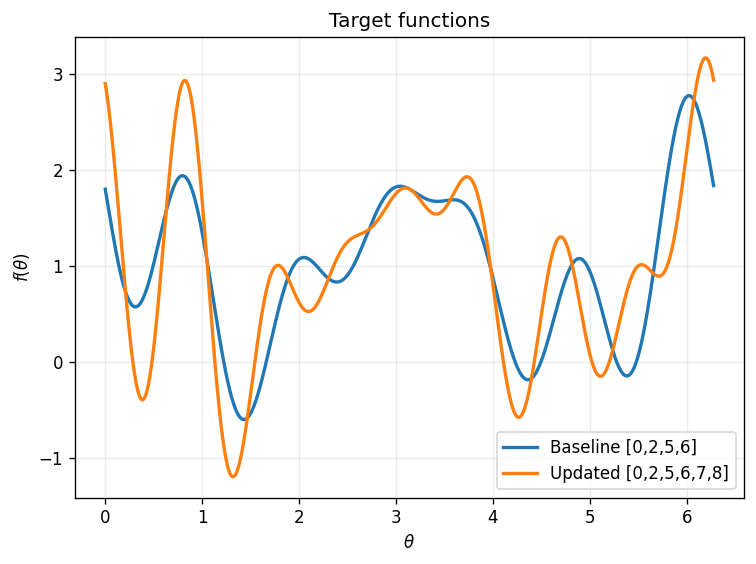

In [5]:
gamma_base = payload['baseline'][256]['gamma_eval']
y_base = payload['baseline'][256]['y_eval_true']
gamma_k78 = payload['k78'][256]['gamma_eval']
y_k78 = payload['k78'][256]['y_eval_true']

if not np.allclose(gamma_base, gamma_k78):
    raise ValueError('Expected same eval grid between baseline and updated runs.')

fig, axes = plt.subplots(1, 1)
ax0 = axes

ax0.plot(gamma_base, y_base, linewidth=2.0, label='Baseline [0..6]')
ax0.plot(gamma_k78, y_k78, linewidth=2.0, label='Updated [0..8]')
ax0.set_title('Target functions')
ax0.set_xlabel(r'$\theta$')
ax0.set_ylabel(r'$f(\theta)$')
ax0.grid(True, alpha=0.25)
ax0.legend()

fig.tight_layout()
filename = PLOT_DIR / 'target_function_baseline_vs_k78.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## Least-Squares Objective Curves (Frozen vs Evolving)

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_old_vs_new_target_comparison/train_ls_baseline_vs_k78_by_width.png


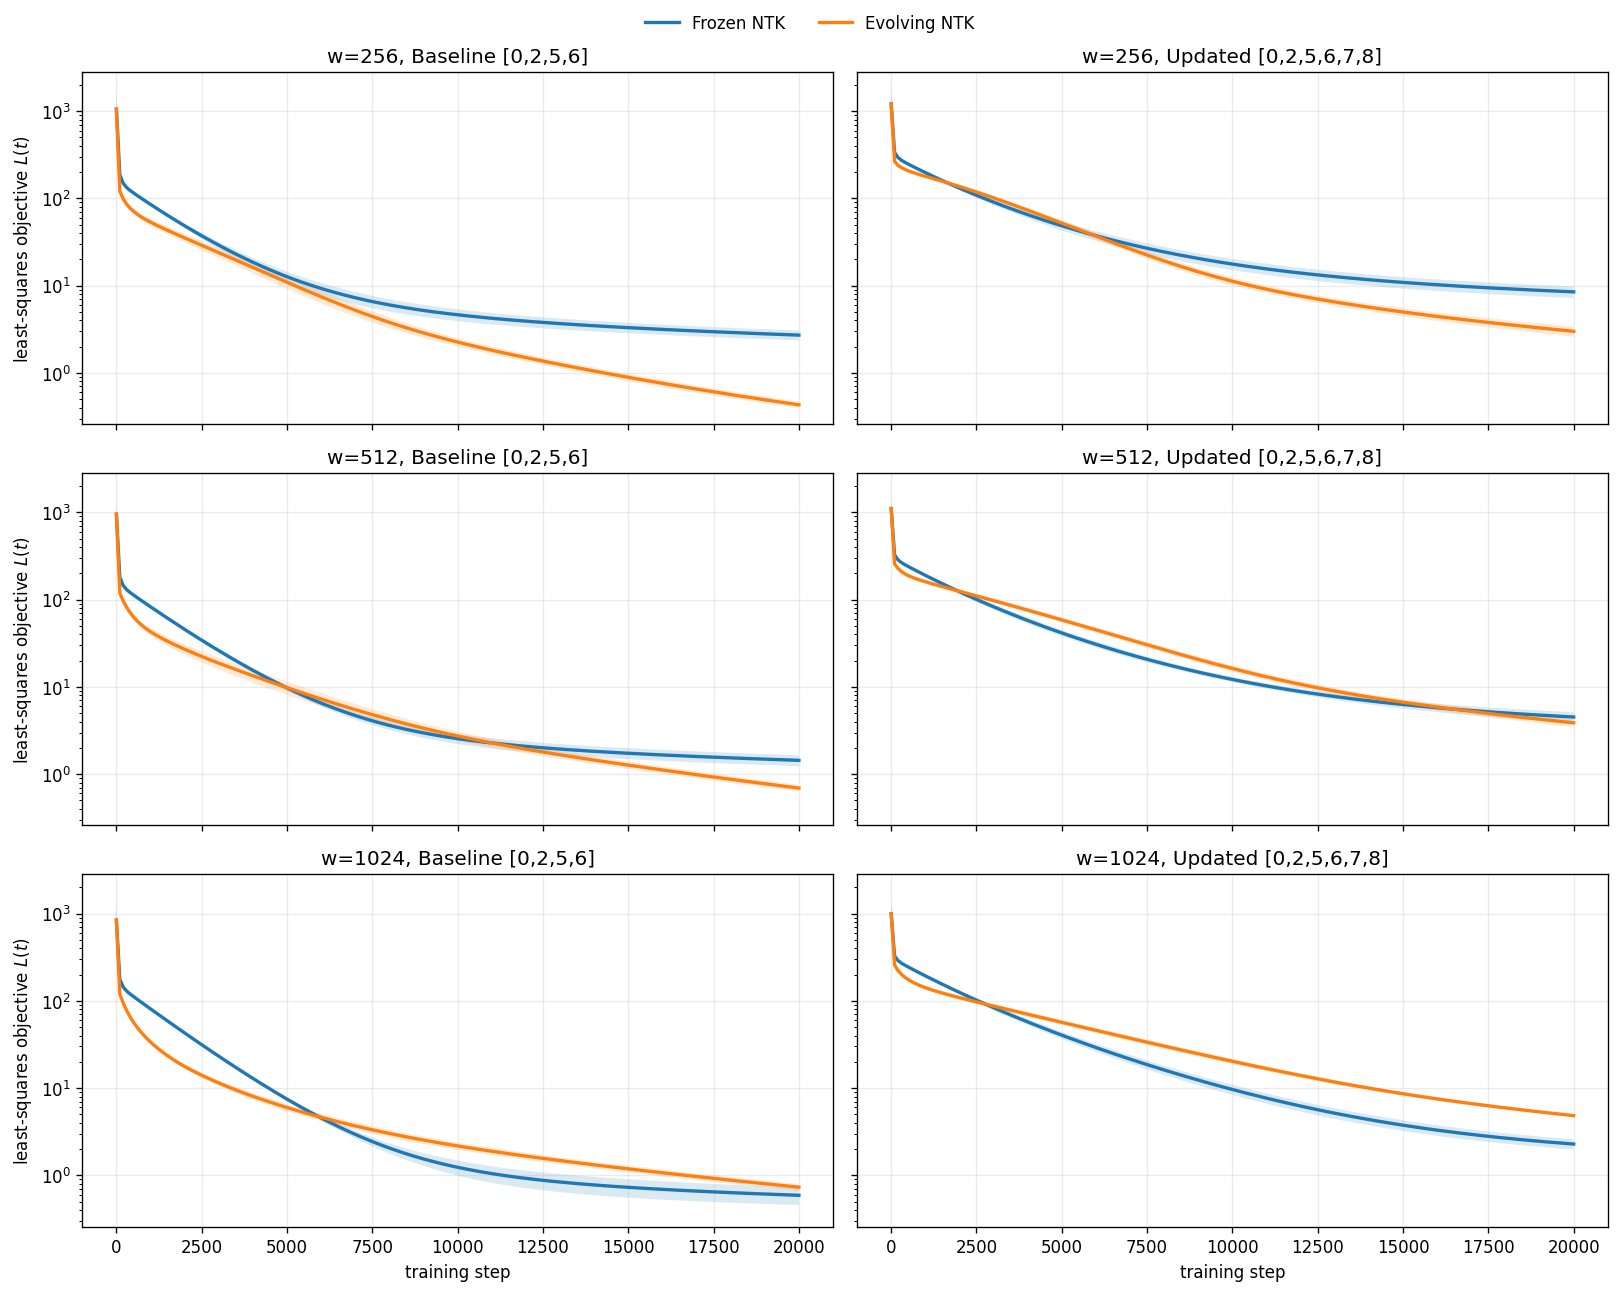

In [8]:
case_keys = ['baseline', 'k78']
fig, axes = plt.subplots(len(WIDTHS), len(case_keys), figsize=(13.6, 10.8), sharex=True, sharey=True)

for r, w in enumerate(WIDTHS):
    for c, case_key in enumerate(case_keys):
        ax = axes[r, c]
        p = payload[case_key][w]
        steps = p['steps']

        mf, sf = seed_mean_std(p['loss_frozen'])
        me, se = seed_mean_std(p['loss_evolving'])

        ax.plot(steps, mf, linewidth=2.0, label='Frozen NTK')
        ax.fill_between(steps, np.maximum(mf - sf, 1e-16), mf + sf, alpha=0.16)

        ax.plot(steps, me, linewidth=2.0, label='Evolving NTK')
        ax.fill_between(steps, np.maximum(me - se, 1e-16), me + se, alpha=0.16)

        ax.set_yscale('log')
        ax.grid(True, alpha=0.25)
        ax.set_title(f'w={w}, {CASE_SPECS[case_key]["label"]}')

        if r == len(WIDTHS) - 1:
            ax.set_xlabel('training step')
        if c == 0:
            ax.set_ylabel(r'least-squares objective $L(t)$')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
# fig.suptitle('Frozen vs evolving least-squares objective', y=0.995)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.98])

filename = PLOT_DIR / 'train_ls_baseline_vs_k78_by_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Reversal Diagnostic: Evolving/Frozen Objective Ratio

Ratio > 1 means evolving has higher LS objective than frozen.

Successfully saved /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/notebooks/plots/ntk_frozen_vs_evolving_old_vs_new_target_comparison/ls_ratio_evolving_over_frozen_baseline_vs_k78.png


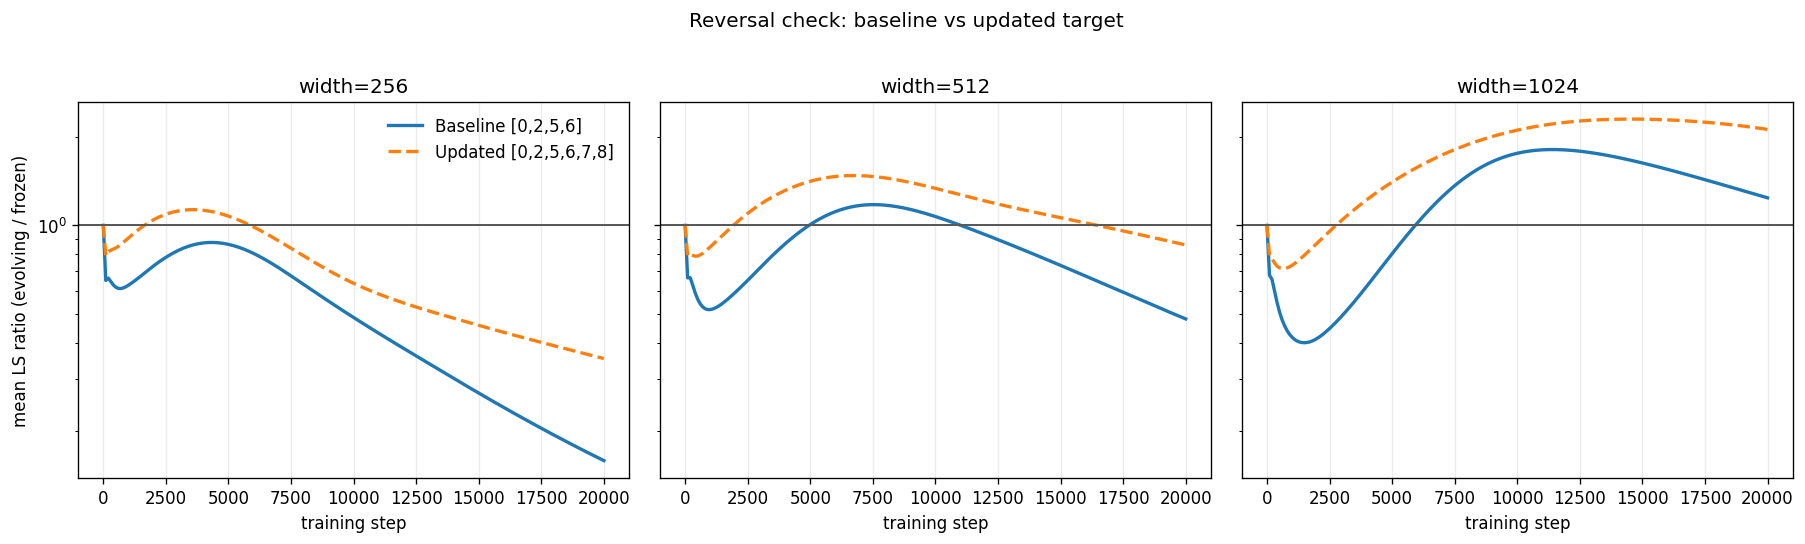

In [9]:
fig, axes = plt.subplots(1, len(WIDTHS), figsize=(15.2, 4.4), sharey=True)

for idx, w in enumerate(WIDTHS):
    ax = axes[idx]
    for case_key, style in [('baseline', '-'), ('k78', '--')]:
        p = payload[case_key][w]
        steps = p['steps']

        mf, _ = seed_mean_std(p['loss_frozen'])
        me, _ = seed_mean_std(p['loss_evolving'])
        ratio = me / np.maximum(mf, 1e-16)

        ax.plot(steps, ratio, linestyle=style, linewidth=2.0, label=CASE_SPECS[case_key]['label'])

    ax.axhline(1.0, color='0.35', linewidth=1.2)
    ax.set_yscale('log')
    ax.set_title(f'width={w}')
    ax.set_xlabel('training step')
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel('mean LS ratio (evolving / frozen)')
axes[0].legend(frameon=False)
fig.suptitle('Reversal check: baseline vs updated target', y=1.02)
fig.tight_layout()

filename = PLOT_DIR / 'ls_ratio_evolving_over_frozen_baseline_vs_k78.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Final-Step Summary (Least Squares)

In [10]:
print('Final-step least-squares objective (mean +- std over seeds)')
print('-' * 86)
for w in WIDTHS:
    print(f'\nwidth={w}')
    for case_key in ['baseline', 'k78']:
        p = payload[case_key][w]
        mf, sf = seed_mean_std(p['loss_frozen'])
        me, se = seed_mean_std(p['loss_evolving'])

        f_end, f_std = float(mf[-1]), float(sf[-1])
        e_end, e_std = float(me[-1]), float(se[-1])
        better = 'frozen' if f_end < e_end else 'evolving'

        print(
            f'  {CASE_SPECS[case_key]["label"]:28s} | '
            f'frozen={f_end:.6e} +- {f_std:.2e} | '
            f'evolving={e_end:.6e} +- {e_std:.2e} | '
            f'better={better}'
        )

Final-step least-squares objective (mean +- std over seeds)
--------------------------------------------------------------------------------------

width=256
  Baseline [0,2,5,6]           | frozen=2.713428e+00 +- 3.50e-01 | evolving=4.315735e-01 +- 3.79e-02 | better=evolving
  Updated [0,2,5,6,7,8]        | frozen=8.498313e+00 +- 1.29e+00 | evolving=3.000802e+00 +- 4.13e-01 | better=evolving

width=512
  Baseline [0,2,5,6]           | frozen=1.438869e+00 +- 2.07e-01 | evolving=6.925941e-01 +- 6.13e-02 | better=evolving
  Updated [0,2,5,6,7,8]        | frozen=4.514900e+00 +- 6.18e-01 | evolving=3.875560e+00 +- 4.08e-01 | better=evolving

width=1024
  Baseline [0,2,5,6]           | frozen=5.900234e-01 +- 1.33e-01 | evolving=7.317542e-01 +- 6.65e-02 | better=frozen
  Updated [0,2,5,6,7,8]        | frozen=2.282946e+00 +- 3.07e-01 | evolving=4.833973e+00 +- 1.66e-01 | better=frozen
